## Saving a Cats v Dogs Model

This is a minimal example showing how to train a fastai model on Kaggle, and save it so you can use it in your app.

In [1]:
# Make sure we've got the latest version of fastai:
!pip install -Uqq fastai

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-io 0.21.0 requires tensorflow-io-gcs-filesystem==0.21.0, which is not installed.
tensorflow 2.6.3 requires absl-py~=0.10, but you have absl-py 1.0.0 which is incompatible.
tensorflow 2.6.3 requires numpy~=1.19.2, but you have numpy 1.21.6 which is incompatible.
tensorflow 2.6.3 requires six~=1.15.0, but you have six 1.16.0 which is incompatible.
tensorflow 2.6.3 requires wrapt~=1.12.1, but you have wrapt 1.14.0 which is incompatible.
tensorflow-transform 1.7.0 requires pyarrow<6,>=1, but you have pyarrow 7.0.0 which is incompatible.
tensorflow-transform 1.7.0 requires tensorflow!=2.0.*,!=2.1.*,!=2.2.*,!=2.3.*,!=2.4.*,!=2.5.*,!=2.6.*,!=2.7.*,<2.9,>=1.15.5, but you have tensorflow 2.6.3 which is incompatible.
tensorflow-serving-api 2.8.0 requires tensorflow<3,>=2.8.0, but you have tensorflow 2.6.3 which i

First, import all the stuff we need from fastai:

In [2]:
from fastai.vision.all import *

Download and decompress our dataset, which is pictures of dogs and cats:

In [3]:
path = untar_data(URLs.PETS)/'images'

We need a way to label our images as dogs or cats. In this dataset, pictures of cats are given a filename that starts with a capital letter:

In [4]:
# the input is the name of a file. 
# if the first letter of a file is uppercase then its a cat file
def is_cat(x): return x[0].isupper() 

Now we can create our `DataLoaders`:

In [5]:
dls = ImageDataLoaders.from_name_func('.',
    get_image_files(path), valid_pct=0.2, seed=42,
    label_func=is_cat,
    item_tfms=Resize(192))

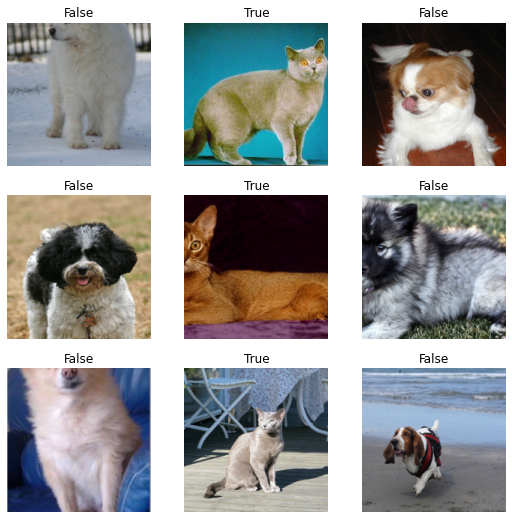

In [6]:
dls.show_batch()

... and train our model, a resnet18 (to keep it small and fast):

In [7]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)
# epoch - is the training run that we are on

# train loss - How wrong the model's predictions are on the training data. Lower is better.
#              The model uses this to adjust its weights AND also considers confidence of decision

# valid_loss — How wrong the model's predictions are on the validation data (the 20% it never trained on). 
#              This is the more honest measure of performance.

# error_rate — The percentage of images the model classified incorrectly on the validation set. 
#              0.01 = 1% error rate. (also considers the confidence of decision)



# overfitting is when train loss is much lower that valid loss.
# it is basically remembering the training data rather than 
# learning general patterns. (does good on seen data but bad on new data)

# HOW TO TELL IF YOUR MODEL IS IN GOOD SHAPE: (BASICALLY TRAINLOSS AND VALID LOSS SHOULD BOTH GO DOWN)
# Train loss much lower than valid loss — the model is overfitting. It's essentially memorizing the training data rather than learning general patterns, so it performs well on data it's seen but poorly on new data.
# Both decreasing together — healthy training, the model is genuinely learning.
# Valid loss increasing while train loss decreases — a clear sign of overfitting, and you should probably stop training.
# Looking at your results, the train loss went from 0.082 → 0.042 → 0.017 across the three epochs, which drops quite aggressively. However the valid loss also dropped from 0.037 → 0.036 → 0.026, so both are moving in the right direction. The fact that train loss is lower than valid loss is normal and expected — the model has seen the training data many times, so it naturally performs better on it. The key is that valid loss is still improving and not rising, which means your model is in good shape.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

epoch,train_loss,valid_loss,error_rate,time
0,0.203971,0.064829,0.023004,00:30


epoch,train_loss,valid_loss,error_rate,time
0,0.073950,0.059438,0.019621,00:25
1,0.054094,0.020052,0.006766,00:25
2,0.023955,0.025443,0.008796,00:25


Now we can export our trained `Learner`. This contains all the information needed to run the model:

In [8]:
learn.export('model.pkl')

Finally, open the Kaggle sidebar on the right if it's not already, and find the section marked "Output". Open the `/kaggle/working` folder, and you'll see `model.pkl`. Click on it, then click on the menu on the right that appears, and choose "Download". After a few seconds, your model will be downloaded to your computer, where you can then create your app that uses the model.